In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df1 = pd.read_excel('river17.xlsx')
df2 = pd.read_excel('river18.xlsx')
df3 = pd.read_excel('river19.xlsx')
df4 = pd.read_excel('river19.xlsx')
df5 = pd.read_excel('minor17.xlsx')
df6 = pd.read_excel('minor18.xlsx')
df7 = pd.read_excel('minor19.xlsx')
df8 = pd.read_excel('minor20.xlsx')
df9 = pd.read_excel('minor21.xlsx')
df10 = pd.read_excel('ponds23.xlsx')
df11 = pd.read_excel('ponds24.xlsx')


In [ ]:
import pandas as pd

files = {
    'river17.xlsx':  {'year': 2017, 'category': 'river'},
    'river18.xlsx':  {'year': 2018, 'category': 'river'},
    'river19.xlsx':  {'year': 2019, 'category': 'river'},
    'river20.xlsx':  {'year': 2020, 'category': 'river'},
    'minor17.xlsx':  {'year': 2017, 'category': 'minor'},
    'minor18.xlsx':  {'year': 2018, 'category': 'minor'},
    'minor19.xlsx':  {'year': 2019, 'category': 'minor'},
    'minor20.xlsx':  {'year': 2020, 'category': 'minor'},
    'minor21.xlsx':  {'year': 2021, 'category': 'minor'},
    'ponds23.xlsx':  {'year': 2023, 'category': 'pond'},
    'ponds24.xlsx':  {'year': 2024, 'category': 'pond'},
}

dfs = []
for fname, meta in files.items():
    df = pd.read_excel(fname)
    df['Year'] = meta['year']
    df['Category'] = meta['category']
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)

print(merged.shape)
print(merged['Category'].value_counts())
print(merged['Year'].value_counts().sort_index())

merged.to_csv('cpcb_merged_all.csv', index=False)

(7157, 22)
Category
river    3992
minor    1662
pond     1503
Name: count, dtype: int64
Year
2017    1196
2018    1264
2019    1472
2020    1399
2021     323
2023     748
2024     755
Name: count, dtype: int64


In [ ]:
merged = pd.read_csv("cpcb_merged_all.csv")
merged[merged['State Name'].isna()][['STN Code','Name of Monitoring Location']]


,STN Code,Name of Monitoring Location
763,2771,TUNGABHADRA AT DADESUGUR ...
890,1212,WARDHA AT RAJURA BRIDGE
891,1228,"ANAS AT DAHOD, (KUSHALGARH),..."


In [ ]:
state_fixes = {
    'UTTARAKHA ND': 'UTTARAKHAND',
    'UTTAR\nPRADESH': 'UTTAR PRADESH',
    'PUDUCHER RY': 'PUDUCHERRY',
    'Odisha': 'ODISHA',
    'MEGHALAY A': 'MEGHALAYA',
    'MADHYA\nPRADESH': 'MADHYA PRADESH',
    'LAKSHADW EEP': 'LAKSHADWEEP',
    'Karnataka': 'KARNATAKA',
}

merged['State Name'] = merged['State Name'].replace(state_fixes)

# also strip any stray newlines/extra spaces elsewhere, then re-check
merged['State Name'] = merged['State Name'].astype(str).str.replace('\n', '', regex=False).str.strip()

In [ ]:
state_fixes = {
    'CHANDIGAR H': 'CHANDIGARH',
    'CHHATTISG ARH': 'CHATTISGARH',
    'CHHATTISGAR H': 'CHATTISGARH',
    'DAMAN, DIU, DADRA NAGAR HAVELI': 'DAMAN AND DIU, DADRA AND NAGAR HAVELI',
    'JHARKHAN D': 'JHARKHAND'
}

merged['State Name'] = merged['State Name'].replace(state_fixes)

# drop INTER-STATE rows
before = len(merged)
merged = merged[merged['State Name'] != 'INTER-STATE'].reset_index(drop=True)
print(f"Dropped {before - len(merged)} INTER-STATE rows. Remaining: {len(merged)}")

print(sorted(merged['State Name'].unique()))

Dropped 0 INTER-STATE rows. Remaining: 7126
['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHATTISGARH', 'DAMAN AND DIU, DADRA AND NAGAR HAVELI', 'DELHI', 'GOA', 'GUJARAT', 'Gujarat', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'Maharashtra', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'RD_BANGALORE', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']


In [ ]:
state_fixes = {
    2771: 'Maharashtra',
    1212: 'Karnataka',
    1228: 'Gujarat'
}
for code, state in state_fixes.items():
    merged.loc[merged['STN Code'] == code, 'State Name'] = state

In [ ]:
col = 'Min Temperature'

# Step 1: group-wise MINIMUM fill — Water Body Type + State
merged[col] = merged.groupby(['Type Water Body', 'State Name'])[col].transform(
    lambda x: x.fillna(x.min())
)

# Step 2: fallback — Water Body Type only
merged[col] = merged.groupby('Type Water Body')[col].transform(
    lambda x: x.fillna(x.min())
)

# Step 3: final fallback — global minimum
merged[col] = merged[col].fillna(merged[col].min())

print("Remaining NaNs:", merged[col].isna().sum())

Remaining NaNs: 0


In [ ]:
col = 'Max Temperature'

# Step 1: group-wise MINIMUM fill — Water Body Type + State
merged[col] = merged.groupby(['Type Water Body', 'State Name'])[col].transform(
    lambda x: x.fillna(x.min())
)

# Step 2: fallback — Water Body Type only
merged[col] = merged.groupby('Type Water Body')[col].transform(
    lambda x: x.fillna(x.max())
)

# Step 3: final fallback — global minimum
merged[col] = merged[col].fillna(merged[col].max())

print("Remaining NaNs:", merged[col].isna().sum())

Remaining NaNs: 0


In [ ]:
# Min Dissolved Oxygen — fill with group MINIMUM
col = 'Min Dissolved Oxygen'
merged[col] = merged.groupby(['Type Water Body', 'State Name'])[col].transform(lambda x: x.fillna(x.min()))
merged[col] = merged.groupby('Type Water Body')[col].transform(lambda x: x.fillna(x.min()))
merged[col] = merged[col].fillna(merged[col].min())
print(col, "remaining NaNs:", merged[col].isna().sum())

# Max Dissolved Oxygen — fill with group MAXIMUM
col = 'Max Dissolved Oxygen'
merged[col] = merged.groupby(['Type Water Body', 'State Name'])[col].transform(lambda x: x.fillna(x.max()))
merged[col] = merged.groupby('Type Water Body')[col].transform(lambda x: x.fillna(x.max()))
merged[col] = merged[col].fillna(merged[col].max())
print(col, "remaining NaNs:", merged[col].isna().sum())

Min Dissolved Oxygen remaining NaNs: 0
Max Dissolved Oxygen remaining NaNs: 0


In [ ]:
col = 'Min pH'
merged[col] = merged[col].fillna(merged[col].min())
print(col, "remaining NaNs:", merged[col].isna().sum())

Min pH remaining NaNs: 0


In [ ]:
col = 'Max pH'

# compute missing % per state
missing_pct = merged.groupby('State Name')[col].apply(lambda x: x.isna().mean() * 100)

# bucket states into 3 tiers
low_missing_states = missing_pct[missing_pct < 5].index
high_missing_states = missing_pct[missing_pct > 10].index
mid_missing_states = missing_pct[(missing_pct >= 5) & (missing_pct <= 10)].index

print("Fill with MAX  :", list(low_missing_states))
print("Fill with MEAN :", list(mid_missing_states))
print("Fill with MEDIAN:", list(high_missing_states))

# apply per-state, per-tier fill
def fill_by_tier(group):
    state = group.name
    if state in low_missing_states:
        return group.fillna(group.max())
    elif state in high_missing_states:
        return group.fillna(group.median())
    elif state in mid_missing_states:
        return group.fillna(group.mean())
    return group  # no missing values, untouched

merged[col] = merged.groupby('State Name')[col].transform(fill_by_tier)

print("Remaining NaNs:", merged[col].isna().sum())

Fill with MAX  : ['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGAR H', 'CHANDIGARH', 'CHATTISGARH', 'CHHATTISG ARH', 'CHHATTISGARH', 'DAMAN, DIU, DADRA NAGAR HAVELI', 'DELHI', 'Gujarat', 'HIMACHAL PRADESH', 'INTER-STATE', 'JAMMU & KASHMIR', 'JHARKHAN D', 'JHARKHAND', 'KARNATAKA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'Maharashtra', 'NAGALAND', 'ODISHA', 'RAJASTHAN', 'RD_BANGALORE', 'SIKKIM', 'TELANGANA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']
Fill with MEAN : ['GUJARAT', 'MAHARASHTRA', 'PUNJAB', 'TAMIL NADU']
Fill with MEDIAN: ['DAMAN AND DIU, DADRA AND NAGAR HAVELI', 'GOA', 'HARYANA', 'KERALA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'PUDUCHERRY', 'TRIPURA']
Remaining NaNs: 0


In [ ]:
def fill_by_missing_tier(df, col, group_col='State Name', low_thresh=5, high_thresh=10):
    missing_pct = df.groupby(group_col)[col].apply(lambda x: x.isna().mean() * 100)
    low_missing = missing_pct[missing_pct < low_thresh].index
    high_missing = missing_pct[missing_pct > high_thresh].index
    mid_missing = missing_pct[(missing_pct >= low_thresh) & (missing_pct <= high_thresh)].index

    def fill_by_tier(group):
        state = group.name
        if state in low_missing:
            return group.fillna(group.max())
        elif state in high_missing:
            return group.fillna(group.median())
        elif state in mid_missing:
            return group.fillna(group.mean())
        return group

    df[col] = df.groupby(group_col)[col].transform(fill_by_tier)
    print(col, "remaining NaNs:", df[col].isna().sum())
    return df

# check missing % first, per column, before trusting the same 5/10 cutoffs
for col in ['Min Conductivity', 'Max Conductivity']:
    print(col)
    print(merged.groupby('State Name')[col].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False))
    print()

Min Conductivity
State Name
JHARKHAND                                66.433566
JHARKHAN D                               57.142857
CHATTISGARH                              48.148148
CHHATTISGARH                             34.939759
DELHI                                    23.809524
UTTARAKHAND                              22.580645
ARUNACHAL PRADESH                        22.222222
KERALA                                    2.968037
UTTAR PRADESH                             2.743902
DAMAN AND DIU, DADRA AND NAGAR HAVELI     2.631579
MADHYA PRADESH                            1.699029
ODISHA                                    0.426439
JAMMU & KASHMIR                           0.420168
TELANGANA                                 0.253807
CHANDIGAR H                               0.000000
BIHAR                                     0.000000
ASSAM                                     0.000000
ANDHRA PRADESH                            0.000000
CHANDIGARH                                0.000000
DAM

In [ ]:
merged = fill_by_missing_tier(merged, 'Min Conductivity')
merged = fill_by_missing_tier(merged, 'Max Conductivity')

Min Conductivity remaining NaNs: 0
Max Conductivity remaining NaNs: 0


In [ ]:
for col in ['Min BOD', 'Max BOD']:
    print(col)
    print(merged.groupby('State Name')[col].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False).head(15))
    print()

Min BOD
State Name
ARUNACHAL PRADESH                        100.000000
LAKSHADWEEP                              100.000000
Gujarat                                   50.000000
JAMMU & KASHMIR                           47.899160
HIMACHAL PRADESH                          44.757033
PUDUCHERRY                                32.142857
UTTARAKHAND                               29.838710
CHATTISGARH                               27.927928
MADHYA PRADESH                            26.941748
DELHI                                     23.809524
NAGALAND                                  22.222222
GUJARAT                                   19.465649
GOA                                       17.391304
DAMAN AND DIU, DADRA AND NAGAR HAVELI     17.021277
ODISHA                                    16.844350
Name: Min BOD, dtype: float64

Max BOD
State Name
ARUNACHAL PRADESH    100.000000
LAKSHADWEEP          100.000000
Gujarat               50.000000
JAMMU & KASHMIR       50.000000
PUDUCHERRY            3

In [ ]:
def fill_by_missing_tier_v2(df, col, group_col='State Name', low_thresh=5, high_thresh=10, extreme_thresh=50):
    missing_pct = df.groupby(group_col)[col].apply(lambda x: x.isna().mean() * 100)
    extreme_missing = missing_pct[missing_pct > extreme_thresh].index
    low_missing = missing_pct[missing_pct < low_thresh].index
    high_missing = missing_pct[(missing_pct > high_thresh) & (missing_pct <= extreme_thresh)].index
    mid_missing = missing_pct[(missing_pct >= low_thresh) & (missing_pct <= high_thresh)].index

    def fill_by_tier(group):
        state = group.name
        if state in extreme_missing:
            return group  # leave for fallback step below
        elif state in low_missing:
            return group.fillna(group.max())
        elif state in high_missing:
            return group.fillna(group.median())
        elif state in mid_missing:
            return group.fillna(group.mean())
        return group

    df[col] = df.groupby(group_col)[col].transform(fill_by_tier)

    # fallback for extreme-missing states: use Water Body Type median instead
    df[col] = df.groupby('Type Water Body')[col].transform(lambda x: x.fillna(x.median()))

    print(col, "remaining NaNs:", df[col].isna().sum())
    return df

merged = fill_by_missing_tier_v2(merged, 'Min BOD')
merged = fill_by_missing_tier_v2(merged, 'Max BOD')

Min BOD remaining NaNs: 0
Max BOD remaining NaNs: 0


In [ ]:
def fill_or_drop_by_tier(df, col, group_col='State Name',
                          low_thresh=5, mid_thresh=30, high_thresh=65):
    missing_pct = df.groupby(group_col)[col].apply(lambda x: x.isna().mean() * 100)

    drop_states  = missing_pct[missing_pct > high_thresh].index
    low_states   = missing_pct[missing_pct < low_thresh].index
    mid_states   = missing_pct[(missing_pct >= low_thresh) & (missing_pct < mid_thresh)].index
    high_states  = missing_pct[(missing_pct >= mid_thresh) & (missing_pct <= high_thresh)].index

    print(f"{col} — dropping rows for states:", list(drop_states))

    # drop rows for extreme-missing states
    df = df[~df[group_col].isin(drop_states)].reset_index(drop=True)

    def fill_by_tier(group):
        state = group.name
        if state in low_states:
            return group.fillna(group.min())
        elif state in mid_states:
            return group.fillna(group.mean())
        elif state in high_states:
            return group.fillna(group.median())
        return group

    df[col] = df.groupby(group_col)[col].transform(fill_by_tier)
    print(col, "remaining NaNs:", df[col].isna().sum())
    return df

merged = fill_or_drop_by_tier(merged, 'Min Nitrate N + Nitrite N')
merged = fill_or_drop_by_tier(merged, 'Max Nitrate N + Nitrite N')

Min Nitrate N + Nitrite N — dropping rows for states: ['ARUNACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'LAKSHADWEEP', 'UTTARAKHAND']
Min Nitrate N + Nitrite N remaining NaNs: 0
Max Nitrate N + Nitrite N — dropping rows for states: ['MANIPUR']
Max Nitrate N + Nitrite N remaining NaNs: 0


In [ ]:
merged.columns

Index(['STN Code', 'Name of Monitoring Location', 'Type Water Body',
       'State Name', 'Min Temperature', 'Max Temperature',
       'Min Dissolved Oxygen', 'Max Dissolved Oxygen', 'Min pH', 'Max pH',
       'Min Conductivity', 'Max Conductivity', 'Min BOD', 'Max BOD',
       'Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N',
       'Min Fecal Coliform', 'Max Fecal Coliform', 'Min Total Coliform',
       'Max Total Coliform', 'Year', 'Category'],
      dtype='object')

In [ ]:
merged = merged.drop(['Type Water Body','Min Fecal Coliform','Max Fecal Coliform','Min Total Coliform','Max Total Coliform'],axis=1)

In [ ]:
merged.shape

(6389, 17)

In [ ]:
before = len(merged)

# Physically impossible bounds per parameter
conditions = (
    (merged['Max pH'] <= 14) & (merged['Min pH'] >= 0) &
    (merged['Max Temperature'] <= 50) & (merged['Min Temperature'] >= 0) &
    (merged['Max Dissolved Oxygen'] <= 20) & (merged['Min Dissolved Oxygen'] >= 0)
)

removed = merged[~conditions]
print("Rows being removed:", len(removed))
print(removed[['STN Code','State Name','Min pH','Max pH','Min Temperature','Max Temperature',
                'Min Dissolved Oxygen','Max Dissolved Oxygen']])

merged = merged[conditions].reset_index(drop=True)

print("Before:", before, "| After:", len(merged), "| Removed:", before - len(merged))

Rows being removed: 32
      STN Code     State Name  Min pH  Max pH  Min Temperature  \
174       2497  UTTAR PRADESH     7.2     7.8             16.0   
1120      1498  UTTAR PRADESH     7.2     8.3              0.0   
1348      2496  UTTAR PRADESH     7.3     7.7             16.0   
1349      2497  UTTAR PRADESH     7.2     7.7             17.0   
1955      1357  UTTAR PRADESH     7.5     8.1             22.0   
1956      1358  UTTAR PRADESH     6.7     7.6             16.0   
1992      1478  UTTAR PRADESH     7.1     7.1              0.0   
1994      1483  UTTAR PRADESH     7.1     7.5              0.0   
2208      2496  UTTAR PRADESH     7.4     7.8             15.0   
2209      2497  UTTAR PRADESH     7.3     7.8             16.0   
2600     10025         PUNJAB     7.1     7.8             14.0   
2601     10026         PUNJAB     7.1     7.5             13.0   
2619     10098  UTTAR PRADESH     7.7     8.3             21.0   
2620     10100  UTTAR PRADESH     7.3     7.7        

In [ ]:
print("Top 15 Min BOD:")
print(merged.nlargest(15, 'Min BOD')[['STN Code','Name of Monitoring Location','State Name','Category','Min BOD','Max BOD']])

print("\nTop 15 Max Conductivity:")
print(merged.nlargest(15, 'Max Conductivity')[['STN Code','Name of Monitoring Location','State Name','Category','Min Conductivity','Max Conductivity']])

Top 15 Min BOD:
      STN Code                        Name of Monitoring Location  \
4874      2671  RIVER KUNDALIKA NEAR SALAV BRIDGE (SALINA ZONE...   
4902      3186                        RIVER MANDOVI AT IFFI JETTY   
4735      1400       RIVER MANDOVI AT NEGHBOURHOOD OF PANAJI, GOA   
4904      3188                           RIVER TIRACOL AT TIRACOL   
4903      3187                   RIVER MANDOVI NEAR HOTEL MARRIOT   
4905      3189                            RIVER CHAPORA AT SIOLIM   
2799      1207                       KABINI AT MUTHANKARA, KERALA   
4825      2294                      RIVER KALLAI AT KALLAI BRIDGE   
5543      5182                KOCHI LAKE AT GOSHREE BRIDGE, KOCHI   
5546      5185           KOCHI LAKE NEAR WELLINGTON ISLAND, KOCHI   
6230      5185           KOCHI LAKE NEAR WELLINGTON ISLAND, KOCHI   
4811      2273       RIVER SAL NEAR HOTEL LEELA MOBOR, CAVELOSSIM   
4835      2304                         RIVER MOGRAL AT MOGRAL BR.   
4970     10012  RI

In [ ]:
# Find all rows where Min > Max (logically impossible)
bod_violations = merged[merged['Min BOD'] > merged['Max BOD']]
print(f"Min BOD > Max BOD violations: {len(bod_violations)}")

# Swap them — assume the value is real but columns got flipped for these rows
mask = merged['Min BOD'] > merged['Max BOD']
merged.loc[mask, ['Min BOD', 'Max BOD']] = merged.loc[mask, ['Max BOD', 'Min BOD']].values

print(merged[['Min BOD','Max BOD']].describe())

Min BOD > Max BOD violations: 332
           Min BOD       Max BOD
count  6357.000000   6357.000000
mean      2.508833    361.497026
std       7.171694   3803.813175
min       0.000000      0.000000
25%       1.000000      2.000000
50%       1.300000      3.000000
75%       2.600000      8.000000
max     206.000000  59470.000000


In [ ]:
# basic summary stats — mean, std, min, max, quartiles
numeric_cols = ['Min Temperature','Max Temperature','Min Dissolved Oxygen','Max Dissolved Oxygen',
                 'Min pH','Max pH','Min Conductivity','Max Conductivity','Min BOD','Max BOD',
                 'Min Nitrate N + Nitrite N','Max Nitrate N + Nitrite N']
merged[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Min Temperature,6357.0,20.003225,5.888679,0.0,17.00,21.00,24.00,35.00
Max Temperature,6357.0,28.932437,5.571492,0.0,27.00,30.00,32.00,46.00
Min Dissolved Oxygen,6357.0,4.902103,2.215341,0.0,3.90,5.50,6.50,10.20
Max Dissolved Oxygen,6357.0,7.614581,2.013212,0.0,6.80,7.60,8.60,19.80
Min pH,6357.0,7.030197,0.571717,1.5,6.70,7.10,7.40,9.50
Max pH,6357.0,8.107170,0.496360,3.0,7.80,8.10,8.40,14.00
Min Conductivity,6357.0,444.506984,1742.410226,0.0,100.00,201.00,347.00,37020.00
Max Conductivity,6357.0,3302.603193,15984.269445,0.0,263.00,507.00,1205.00,513000.00
Min BOD,6357.0,2.508833,7.171694,0.0,1.00,1.30,2.60,206.00
Max BOD,6357.0,361.497026,3803.813175,0.0,2.00,3.00,8.00,59470.00


In [ ]:
import numpy as np

skewed_cols = ['Min Conductivity', 'Max Conductivity', 'Min BOD', 'Max BOD',
               'Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N']

for col in skewed_cols:
    merged[col] = np.log1p(merged[col])


In [ ]:
merged.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,...,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Max Conductivity_log,Min BOD_log,Max BOD_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,...,0.182322,0.182322,2017,river,4.532599,5.905362,0.09531,0.182322,0.182322,0.182322
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,...,0.182322,0.405465,2017,river,4.442651,5.793014,0.09531,0.405465,0.182322,0.405465
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,...,0.182322,0.336472,2017,river,4.532599,5.802118,0.09531,0.405465,0.182322,0.336472
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,...,0.182322,0.292670,2017,river,4.682131,5.736572,0.09531,0.336472,0.182322,0.292670
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,...,0.182322,0.414094,2017,river,4.634729,5.700444,0.09531,0.182322,0.182322,0.414094


In [ ]:
merged = merged.drop(merged.columns[-5:], axis=1)

In [ ]:
merged[numeric_cols].skew()
merged[numeric_cols].kurtosis()

,0
Min Temperature,1.264336
Max Temperature,8.401266
Min Dissolved Oxygen,-0.213887
Max Dissolved Oxygen,3.192434
Min pH,14.291916
Max pH,10.300376
Min Conductivity,2.134227
Max Conductivity,2.297772
Min BOD,5.669379
Max BOD,11.131729


In [ ]:
for col in numeric_cols:
    Q1 = merged[col].quantile(0.25)
    Q3 = merged[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = merged[(merged[col] < Q1 - 1.5*IQR) | (merged[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(merged)*100:.1f}%)")

Min Temperature: 220 outliers (3.5%)
Max Temperature: 366 outliers (5.8%)
Min Dissolved Oxygen: 0 outliers (0.0%)
Max Dissolved Oxygen: 512 outliers (8.1%)
Min pH: 92 outliers (1.4%)
Max pH: 109 outliers (1.7%)
Min Conductivity: 425 outliers (6.7%)
Max Conductivity: 345 outliers (5.4%)
Min BOD: 239 outliers (3.8%)
Max BOD: 545 outliers (8.6%)
Min Nitrate N + Nitrite N: 541 outliers (8.5%)
Max Nitrate N + Nitrite N: 285 outliers (4.5%)


In [ ]:
print("BOD violations:", (merged['Min BOD'] > merged['Max BOD']).sum())
print("Nitrate violations:", (merged['Min Nitrate N + Nitrite N'] > merged['Max Nitrate N + Nitrite N']).sum())

BOD violations: 0
Nitrate violations: 398


In [ ]:
mask = merged['Min Nitrate N + Nitrite N'] > merged['Max Nitrate N + Nitrite N']
print(f"Swapping {mask.sum()} Nitrate rows")

merged.loc[mask, ['Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N']] = \
    merged.loc[mask, ['Max Nitrate N + Nitrite N', 'Min Nitrate N + Nitrite N']].values

# confirm fix
print("Remaining violations:", (merged['Min Nitrate N + Nitrite N'] > merged['Max Nitrate N + Nitrite N']).sum())

Swapping 398 Nitrate rows
Remaining violations: 0


In [ ]:
merged['Min Nitrate N + Nitrite N_log'] = np.log1p(merged['Min Nitrate N + Nitrite N'])
merged['Max Nitrate N + Nitrite N_log'] = np.log1p(merged['Max Nitrate N + Nitrite N'])

print(merged[['Min Nitrate N + Nitrite N_log','Max Nitrate N + Nitrite N_log']].kurtosis())

Min Nitrate N + Nitrite N_log    4.033802
Max Nitrate N + Nitrite N_log    0.038223
dtype: float64


In [ ]:
merged.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,Max Conductivity,Min BOD,Max BOD,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,5.905362,0.09531,0.182322,0.182322,0.182322,2017,river,4.532599,0.16748,0.167480
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,5.793014,0.09531,0.405465,0.182322,0.405465,2017,river,4.442651,0.16748,0.340368
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,5.802118,0.09531,0.405465,0.182322,0.336472,2017,river,4.532599,0.16748,0.290033
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,5.736572,0.09531,0.336472,0.182322,0.292670,2017,river,4.682131,0.16748,0.256710
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,5.700444,0.09531,0.182322,0.182322,0.414094,2017,river,4.634729,0.16748,0.346489


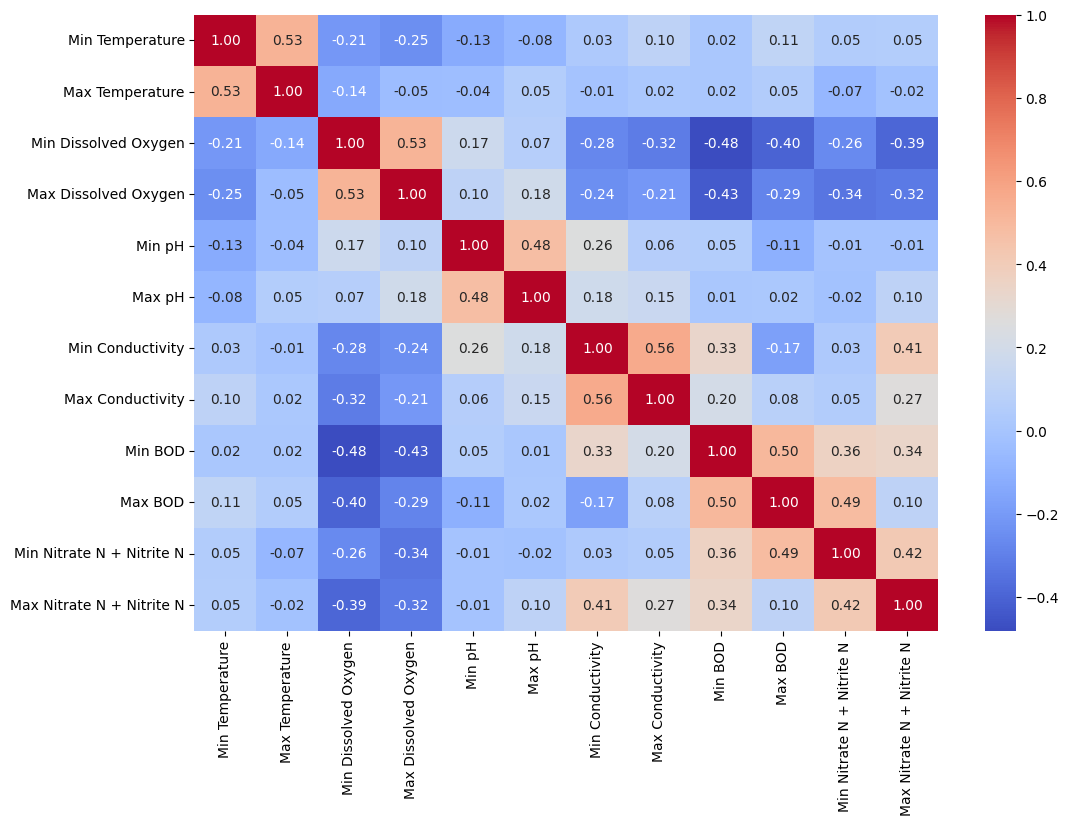

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(merged[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [ ]:
merged.to_csv("cleaned.csv",index=False)

In [ ]:
df1.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,Max Conductivity,Min BOD,Max BOD,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,5.905362,0.09531,0.182322,0.182322,0.182322,2017,river,4.532599,0.16748,0.167480
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,5.793014,0.09531,0.405465,0.182322,0.405465,2017,river,4.442651,0.16748,0.340368
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,5.802118,0.09531,0.405465,0.182322,0.336472,2017,river,4.532599,0.16748,0.290033
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,5.736572,0.09531,0.336472,0.182322,0.292670,2017,river,4.682131,0.16748,0.256710
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,5.700444,0.09531,0.182322,0.182322,0.414094,2017,river,4.634729,0.16748,0.346489


In [ ]:
import numpy as np
df1['Min BOD_log'] = np.log1p(df1['Min BOD'])
df1['Max BOD_log'] = np.log1p(df1['Max BOD'])
df1['Max Conductivity_log'] = np.log1p(df1['Max Conductivity'])

In [ ]:
df1.to_csv("final_cleaned.csv",index=False)

In [ ]:
df = pd.read_csv("final_cleaned.csv")

In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,...,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log,Min BOD_log,Max BOD_log,Max Conductivity_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,...,0.182322,0.182322,2017,river,4.532599,0.16748,0.167480,0.091038,0.167480,1.932298
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,...,0.182322,0.405465,2017,river,4.442651,0.16748,0.340368,0.091038,0.340368,1.915895
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,...,0.182322,0.336472,2017,river,4.532599,0.16748,0.290033,0.091038,0.340368,1.917234
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,...,0.182322,0.292670,2017,river,4.682131,0.16748,0.256710,0.091038,0.290033,1.907551
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,...,0.182322,0.414094,2017,river,4.634729,0.16748,0.346489,0.091038,0.167480,1.902174


In [ ]:
df['State Name'] = df['State Name'].replace({
    'Gujarat': 'GUJARAT',
    'Maharashtra': 'MAHARASHTRA',
})

# check RD_BANGALORE rows before fixing
print(df[df['State Name'] == 'RD_BANGALORE'][['STN Code','Name of Monitoring Location','State Name']])
df.loc[df['State Name'] == 'RD_BANGALORE', 'State Name'] = 'KARNATAKA'
df.to_csv('final_cleaned_v2.csv', index=False)

      STN Code      Name of Monitoring Location    State Name
1696     30052  CAUVERY AT AJJIBORE (BANGALORE)  RD_BANGALORE


In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("final_cleaned_v2.csv")

In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,...,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log,Min BOD_log,Max BOD_log,Max Conductivity_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,...,0.182322,0.182322,2017,river,4.532599,0.16748,0.167480,0.091038,0.167480,1.932298
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,...,0.182322,0.405465,2017,river,4.442651,0.16748,0.340368,0.091038,0.340368,1.915895
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,...,0.182322,0.336472,2017,river,4.532599,0.16748,0.290033,0.091038,0.340368,1.917234
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,...,0.182322,0.292670,2017,river,4.682131,0.16748,0.256710,0.091038,0.290033,1.907551
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,...,0.182322,0.414094,2017,river,4.634729,0.16748,0.346489,0.091038,0.167480,1.902174


In [ ]:
THRESHOLDS = {
    'pH_low': 6.5,
    'pH_high': 8.5,
    'DO_min': 4.0,          # CPCB Class D minimum for aquatic life/general safety
    'BOD_max': 3.0,         # CPCB Class B/C limit
    'Conductivity_max': 2250.0,   # CPCB Class E limit
    'Nitrate_max': 45.0,    # BIS IS 10500:2012 (stricter than WHO's 50)
}

def compute_outbreak_risk(row):
    # pH breach — either min or max outside safe range
    ph_breach = (row['Min pH'] < THRESHOLDS['pH_low']) or (row['Max pH'] > THRESHOLDS['pH_high'])

    # DO breach — minimum reading falling below safe floor
    do_breach = row['Min Dissolved Oxygen'] < THRESHOLDS['DO_min']

    # BOD breach — max reading exceeding safe ceiling (captures the spike)
    bod_breach = row['Max BOD'] > THRESHOLDS['BOD_max']

    # Conductivity breach — max reading exceeding safe ceiling
    conductivity_breach = row['Max Conductivity'] > THRESHOLDS['Conductivity_max']

    # Nitrate breach — max reading exceeding safe ceiling
    nitrate_breach = row['Max Nitrate N + Nitrite N'] > THRESHOLDS['Nitrate_max']

    # outbreak risk = 1 if ANY parameter breaches its threshold
    return int(ph_breach or do_breach or bod_breach or conductivity_breach or nitrate_breach)

df['outbreak_risk'] = df.apply(compute_outbreak_risk, axis=1)

print(df['outbreak_risk'].value_counts())
print(df['outbreak_risk'].value_counts(normalize=True) * 100)

df.to_csv('final_labeled.csv', index=False)

outbreak_risk
0    3486
1    2871
Name: count, dtype: int64
outbreak_risk
0    54.837187
1    45.162813
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
df = pd.read_csv('final_labeled.csv')

In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,...,Max Nitrate N + Nitrite N,Year,Category,Min Conductivity_log,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log,Min BOD_log,Max BOD_log,Max Conductivity_log,outbreak_risk
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,...,0.182322,2017,river,4.532599,0.16748,0.167480,0.091038,0.167480,1.932298,0
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,...,0.405465,2017,river,4.442651,0.16748,0.340368,0.091038,0.340368,1.915895,0
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,...,0.336472,2017,river,4.532599,0.16748,0.290033,0.091038,0.340368,1.917234,0
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,...,0.292670,2017,river,4.682131,0.16748,0.256710,0.091038,0.290033,1.907551,0
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,...,0.414094,2017,river,4.634729,0.16748,0.346489,0.091038,0.167480,1.902174,0


In [ ]:
df['TDS_estimated'] = df['Max Conductivity'] * 0.64
df['TDS_estimated_min'] = df['Min Conductivity'] * 0.64

# sanity check the converted range against typical Indian freshwater TDS (usually 50-1500 mg/L for rivers/ponds)
print(df['TDS_estimated'].describe())

count    6357.000000
mean        4.124248
std         0.906428
min         0.000000
25%         3.568607
50%         3.987508
75%         4.540841
max         8.414741
Name: TDS_estimated, dtype: float64


In [ ]:
import numpy as np

df['TDS_estimated_log'] = np.log1p(df['TDS_estimated'])
df['TDS_estimated_min_log'] = np.log1p(df['TDS_estimated_min'])

print(df[['TDS_estimated_log', 'TDS_estimated_min_log']].describe())
print(df[['TDS_estimated_log', 'TDS_estimated_min_log']].kurtosis())

       TDS_estimated_log  TDS_estimated_min_log
count        6357.000000            6357.000000
mean            1.619285               1.446858
std             0.170355               0.194931
min             0.000000               0.000000
25%             1.519208               1.374646
50%             1.606936               1.480989
75%             1.712146               1.557178
max             2.242277               2.045408
TDS_estimated_log        4.148846
TDS_estimated_min_log    3.815628
dtype: float64


In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,...,Min Nitrate N + Nitrite N_log,Max Nitrate N + Nitrite N_log,Min BOD_log,Max BOD_log,Max Conductivity_log,outbreak_risk,TDS_estimated,TDS_estimated_min,TDS_estimated_log,TDS_estimated_min_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.80,8.00,4.532599,...,0.16748,0.167480,0.091038,0.167480,1.932298,0,3.779432,2.900864,1.564322,1.361198
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,9.7,10.1,6.70,7.90,4.442651,...,0.16748,0.340368,0.091038,0.340368,1.915895,0,3.707529,2.843297,1.549163,1.346331
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,9.1,9.6,6.80,8.10,4.532599,...,0.16748,0.290033,0.091038,0.340368,1.917234,0,3.713356,2.900864,1.550400,1.361198
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.8,9.8,6.96,7.99,4.682131,...,0.16748,0.256710,0.091038,0.290033,1.907551,0,3.671406,2.996564,1.541460,1.385435
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,8.7,9.2,6.91,8.04,4.634729,...,0.16748,0.346489,0.091038,0.167480,1.902174,0,3.648284,2.966227,1.536498,1.377815


In [ ]:
cols_to_drop = [
    # Dissolved Oxygen
    'Min Dissolved Oxygen', 'Max Dissolved Oxygen',
    # Conductivity (raw + log)
    'Min Conductivity', 'Max Conductivity',
    'Min Conductivity_log', 'Max Conductivity_log',
    # BOD (raw + log)
    'Min BOD', 'Max BOD',
    'Min BOD_log', 'Max BOD_log',
    # Nitrate/Nitrite (raw + log)
    'Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N',
    'Min Nitrate N + Nitrite N_log', 'Max Nitrate N + Nitrite N_log',
]

df = df.drop(columns=cols_to_drop, errors='ignore')

print(df.columns.tolist())
print(df.shape)

['STN Code', 'Name of Monitoring Location', 'State Name', 'Min Temperature', 'Max Temperature', 'Min pH', 'Max pH', 'Year', 'Category', 'outbreak_risk', 'TDS_estimated', 'TDS_estimated_min', 'TDS_estimated_log', 'TDS_estimated_min_log']
(6357, 14)


In [ ]:
df.to_csv('final.csv',index=False)

In [ ]:
import pandas as pd
df = pd.read_csv('final.csv')

In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min pH,Max pH,Year,Category,outbreak_risk,TDS_estimated,TDS_estimated_min,TDS_estimated_log,TDS_estimated_min_log
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,6.80,8.00,2017,river,0,3.779432,2.900864,1.564322,1.361198
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,6.70,7.90,2017,river,0,3.707529,2.843297,1.549163,1.346331
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,6.80,8.10,2017,river,0,3.713356,2.900864,1.550400,1.361198
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,6.96,7.99,2017,river,0,3.671406,2.996564,1.541460,1.385435
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,6.91,8.04,2017,river,0,3.648284,2.966227,1.536498,1.377815


In [ ]:
import numpy as np

np.random.seed(42)  # reproducibility — document this in your report

# Base turbidity ranges by water body type, informed by published Indian river/pond studies (NTU)
# Rivers: generally 5-50 NTU baseline, spikes higher during monsoon/pollution events
# Minor rivers/tributaries: similar to rivers, slightly more variable (less flow dilution)
# Ponds: typically higher due to stagnancy, algae, sediment settling less effectively
base_ranges = {
    'river': (5, 50),
    'minor': (5, 60),
    'pond': (10, 80),
}

def generate_synthetic_turbidity(row):
    low, high = base_ranges.get(row['Category'], (5, 50))
    base_value = np.random.uniform(low, high)

    # weak positive nudge from TDS — proxy for human/pollution influence
    # normalize TDS influence so it doesn't dominate (this is a small adjustment, not a formula)
    tds_influence = (row['TDS_estimated'] / row['TDS_estimated'].max() if hasattr(row['TDS_estimated'], 'max') else 0)
    adjustment = np.random.uniform(0, 10) * (row['TDS_estimated'] / 1000)  # scaled nudge

    turbidity = base_value + adjustment
    return max(turbidity, 0.5)  # floor at 0.5 NTU, physically can't be zero/negative

df['Turbidity_synthetic'] = df.apply(generate_synthetic_turbidity, axis=1)

print(df.groupby('Category')['Turbidity_synthetic'].describe())

           count       mean        std        min        25%        50%  \
Category                                                                  
minor     1475.0  31.852838  15.512513   5.041109  18.950947  31.556752   
pond      1373.0  45.625288  20.394766  10.165991  27.992011  45.690266   
river     3509.0  27.304858  13.004693   5.020508  15.862215  27.276297   

                75%        max  
Category                        
minor     44.652952  59.868467  
pond      63.529495  79.915307  
river     38.594753  49.978491  


In [ ]:
df.head()

,STN Code,Name of Monitoring Location,State Name,Min Temperature,Max Temperature,Min pH,Max pH,Year,Category,outbreak_risk,TDS_estimated,TDS_estimated_min,TDS_estimated_log,TDS_estimated_min_log,Turbidity_synthetic
0,1867,SATLUJ RIVER B/C WITH RIVER SPITI ...,HIMACHAL PRADESH,9.0,12.0,6.80,8.00,2017,river,0,3.779432,2.900864,1.564322,1.361198,21.890237
1,2611,SATLUJ AT KHAB,HIMACHAL PRADESH,9.0,12.0,6.70,7.90,2017,river,0,3.707529,2.843297,1.549163,1.346331,37.961923
2,1389,SATLUJ AT NEPTHA ZAKHAI,HIMACHAL PRADESH,12.0,17.0,6.80,8.10,2017,river,0,3.713356,2.900864,1.550400,1.361198,12.026631
3,1086,SATLUJ AT U/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,6.96,7.99,2017,river,0,3.671406,2.996564,1.541460,1.385435,7.645563
4,1087,SATLUJ AT D/S RAMPUR,HIMACHAL PRADESH,14.0,17.0,6.91,8.04,2017,river,0,3.648284,2.966227,1.536498,1.377815,32.076008


In [ ]:
df.to_csv('finale.csv',index=False)

In [ ]:
df = pd.read_csv('finale.csv')

In [ ]:
cols_to_drop = [
    'STN Code',
    'Name of Monitoring Location',
    "State Name",'Category'
]

df_model_ready = df.drop(columns=cols_to_drop, errors='ignore')

print(df_model_ready.columns.tolist())
print(df_model_ready.shape)

df_model_ready.to_csv('final_model_ready.csv', index=False)

['Min Temperature', 'Max Temperature', 'Min pH', 'Max pH', 'Year', 'outbreak_risk', 'TDS_estimated', 'TDS_estimated_min', 'TDS_estimated_log', 'TDS_estimated_min_log', 'Turbidity_synthetic']
(6357, 11)


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # reproducibility — document in report

# Baseline case-count ranges per disease (per row/station-reading context)
# Loosely informed by EpiClim's own reported scale and relative disease prevalence
# (ADD most prevalent, then Dengue, then Cholera; Malaria/Chikungunya lower in most states)
disease_base_ranges = {
    'ADD_cases': (5, 150),         # waterborne — most common
    'Cholera_cases': (0, 30),      # waterborne — rarer but sharper spikes
    'Dengue_cases': (0, 80),       # vector-borne — no water-risk link
    'Malaria_cases': (0, 40),      # vector-borne — no water-risk link
}

def generate_synthetic_cases(row):
    cases = {}
    for disease, (low, high) in disease_base_ranges.items():
        base = np.random.uniform(low, high)

        # Only waterborne diseases get a nudge from water_risk — vector-borne diseases stay independent
        if disease in ['ADD_cases', 'Cholera_cases'] and row.get('water_risk', 0) == 1:
            base *= np.random.uniform(1.5, 3.0)  # contamination plausibly amplifies case count

        cases[disease] = max(round(base), 0)
    return pd.Series(cases)

case_cols = df_model_ready.apply(generate_synthetic_cases, axis=1)
df_with_cases = pd.concat([df_model_ready, case_cols], axis=1)

print(df_with_cases[['ADD_cases','Cholera_cases','Dengue_cases','Malaria_cases']].describe())
df_with_cases.to_csv('final_with_synthetic_cases.csv', index=False)

         ADD_cases  Cholera_cases  Dengue_cases  Malaria_cases
count  6357.000000    6357.000000   6357.000000    6357.000000
mean     77.558597      15.000000     40.264433      20.056473
std      41.451632       8.664304     23.072656      11.662893
min       5.000000       0.000000      0.000000       0.000000
25%      42.000000       8.000000     20.000000      10.000000
50%      78.000000      15.000000     40.000000      20.000000
75%     112.000000      23.000000     60.000000      30.000000
max     150.000000      30.000000     80.000000      40.000000


In [ ]:
df_with_cases.head()

,Min Temperature,Max Temperature,Min pH,Max pH,Year,outbreak_risk,TDS_estimated,TDS_estimated_min,TDS_estimated_log,TDS_estimated_min_log,Turbidity_synthetic,ADD_cases,Cholera_cases,Dengue_cases,Malaria_cases
0,9.0,12.0,6.80,8.00,2017,0,3.779432,2.900864,1.564322,1.361198,21.890237,59,29,59,24
1,9.0,12.0,6.70,7.90,2017,0,3.707529,2.843297,1.549163,1.346331,37.961923,28,5,5,35
2,12.0,17.0,6.80,8.10,2017,0,3.713356,2.900864,1.550400,1.361198,12.026631,92,21,2,39
3,14.0,17.0,6.96,7.99,2017,0,3.671406,2.996564,1.541460,1.385435,7.645563,126,6,15,7
4,14.0,17.0,6.91,8.04,2017,0,3.648284,2.966227,1.536498,1.377815,32.076008,49,16,35,12


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ============================================================
# 1. Load dataset
# ============================================================

df = pd.read_csv("final_with_synthetic_cases.csv")

# ============================================================
# 2. Remove Year only if you don't want temporal information
# ============================================================

# Keep Year initially
# We can test removing it later

# ============================================================
# 3. Create target
# ============================================================

add_thresh = df["ADD_cases"].quantile(0.75)
cholera_thresh = df["Cholera_cases"].quantile(0.75)

waterborne_outbreak = (
    (df["ADD_cases"] > add_thresh) |
    (df["Cholera_cases"] > cholera_thresh)
)

df["outbreak_due_to_water"] = (
    waterborne_outbreak &
    (df["outbreak_risk"] == 1)
).astype(int)

# ============================================================
# 4. Features
# ============================================================

features = [
    "Min Temperature",
    "Max Temperature",
    "Min pH",
    "Max pH",
    "TDS_estimated",
    "TDS_estimated_min",
    "Turbidity_synthetic",
    "Dengue_cases",
    "Malaria_cases"
]

X = df[features]

y = df["outbreak_due_to_water"]

print("X shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

# ============================================================
# 5. Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 6. Random Forest with class weighting
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ============================================================
# 7. Probabilities
# ============================================================

y_prob = rf.predict_proba(X_test)[:, 1]

# ============================================================
# 8. Threshold = 0.22
# ============================================================

threshold = 0.22

y_pred = (y_prob >= threshold).astype(int)

# ============================================================
# 9. Evaluation
# ============================================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nPR-AUC:")
print(average_precision_score(y_test, y_prob))

X shape: (6357, 9)

Class distribution:
outbreak_due_to_water
0    5157
1    1200
Name: count, dtype: int64

RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.65      0.77      1032
           1       0.35      0.82      0.49       240

    accuracy                           0.68      1272
   macro avg       0.65      0.74      0.63      1272
weighted avg       0.83      0.68      0.71      1272


Confusion Matrix:
[[667 365]
 [ 42 198]]

ROC-AUC:
0.7821019056847546

PR-AUC:
0.3653903774021832


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance.to_string(index=False))

            Feature  Importance
             Min pH    0.157102
  TDS_estimated_min    0.153949
      TDS_estimated    0.152049
             Max pH    0.147008
Turbidity_synthetic    0.095983
       Dengue_cases    0.084487
      Malaria_cases    0.075336
    Min Temperature    0.070342
    Max Temperature    0.063744


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

print(perm_importance.to_string(index=False))

            Feature  Importance
             Min pH    0.096531
             Max pH    0.062906
  TDS_estimated_min    0.036365
      TDS_estimated    0.035886
Turbidity_synthetic    0.007276
    Max Temperature    0.005787
    Min Temperature    0.000681
      Malaria_cases   -0.005701
       Dengue_cases   -0.008028


In [ ]:
import joblib
model_data = {
    "model": rf,
    "threshold": 0.22
}
joblib.dump(model_data, "model.pkl")

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [ ]:
import pandas as pd
df = pd.read_csv("final_with_synthetic_cases.csv")
df.head()

,Min Temperature,Max Temperature,Min pH,Max pH,Year,outbreak_risk,TDS_estimated,TDS_estimated_min,TDS_estimated_log,TDS_estimated_min_log,Turbidity_synthetic,ADD_cases,Cholera_cases,Dengue_cases,Malaria_cases
0,9.0,12.0,6.80,8.00,2017,0,3.779432,2.900864,1.564322,1.361198,21.890237,59,29,59,24
1,9.0,12.0,6.70,7.90,2017,0,3.707529,2.843297,1.549163,1.346331,37.961923,28,5,5,35
2,12.0,17.0,6.80,8.10,2017,0,3.713356,2.900864,1.550400,1.361198,12.026631,92,21,2,39
3,14.0,17.0,6.96,7.99,2017,0,3.671406,2.996564,1.541460,1.385435,7.645563,126,6,15,7
4,14.0,17.0,6.91,8.04,2017,0,3.648284,2.966227,1.536498,1.377815,32.076008,49,16,35,12


In [ ]:
columns_to_keep = [
    "TDS_estimated",
    "TDS_estimated_min",
    "Turbidity_synthetic"
]

df.drop(columns=[col for col in df.columns if col not in columns_to_keep], inplace=True)

In [ ]:
print(df[[
    "TDS_estimated",
    "TDS_estimated_min",
    "Turbidity_synthetic"
]].describe())

       TDS_estimated  TDS_estimated_min  Turbidity_synthetic
count    6357.000000        6357.000000          6357.000000
mean        4.124248           3.325140            32.317005
std         0.906428           0.767171            17.061974
min         0.000000           0.000000             5.020508
25%         3.568607           2.953677            18.363830
50%         3.987508           3.397291            31.241849
75%         4.540841           3.745410            43.736930
max         8.414741           6.732314            79.915307


In [ ]:
tds_threshold = df["TDS_estimated"].quantile(0.75)
tds_min_threshold = df["TDS_estimated_min"].quantile(0.75)
turbidity_threshold = df["Turbidity_synthetic"].quantile(0.75)

def check_potability(row):
    if (
        row["TDS_estimated"] <= tds_threshold and
        row["TDS_estimated_min"] <= tds_min_threshold and
        row["Turbidity_synthetic"] <= turbidity_threshold
    ):
        return 1
    else:
        return 0

df["Potable"] = df.apply(check_potability, axis=1)

print(df["Potable"].value_counts())

Potable
1    3239
0    3118
Name: count, dtype: int64


In [ ]:
df.to_csv("water_potability_dataset.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 6357

df_symptoms = pd.DataFrame({
    "Nausea": np.random.randint(0, 4, n),
    "Fever": np.random.randint(0, 4, n),
    "Dehydration": np.random.randint(0, 4, n),
    "Abdominal_Cramps": np.random.randint(0, 4, n),
    "Diarrhoea": np.random.randint(0, 4, n)
})

print(df_symptoms.head())

   Nausea  Fever  Dehydration  Abdominal_Cramps  Diarrhoea
0       2      2            0                 2          1
1       3      3            1                 0          1
2       0      2            0                 1          0
3       2      2            0                 2          2
4       2      3            2                 0          2


In [ ]:
df_symptoms.to_csv("waterborne_symptoms_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
# Create Outbreak column from Potable
df["Outbreak"] = (df["Potable"] == 0).astype(int)

# Merge symptoms + Outbreak only
df_final = pd.concat([
    df_symptoms[[
        "Nausea",
        "Fever",
        "Dehydration",
        "Abdominal_Cramps",
        "Diarrhoea"
    ]],
    df[["Outbreak"]]
], axis=1)

# Check result
print(df_final.head())
print(df_final.shape)
print(df_final.columns)

   Nausea  Fever  Dehydration  Abdominal_Cramps  Diarrhoea  Outbreak
0       2      2            0                 2          1         0
1       3      3            1                 0          1         0
2       0      2            0                 1          0         0
3       2      2            0                 2          2         0
4       2      3            2                 0          2         0
(6357, 6)
Index(['Nausea', 'Fever', 'Dehydration', 'Abdominal_Cramps', 'Diarrhoea',
       'Outbreak'],
      dtype='object')


In [ ]:
df_final.to_csv("outbreak_symptoms_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
# Create a water-quality score
df["Water_Quality_Score"] = (
    df["TDS_estimated"].rank(pct=True) +
    df["TDS_estimated_min"].rank(pct=True) +
    df["Turbidity_synthetic"].rank(pct=True)
) / 3

# Lower score = better water quality
df["Potable"] = (df["Water_Quality_Score"] < 0.50).astype(int)

print(df["Potable"].value_counts())

Potable
1    3304
0    3053
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = len(df)

df_symptoms = pd.DataFrame({
    "Nausea": np.random.choice(
    [0, 1, 2, 3], n,
    p=[0.50, 0.25, 0.15, 0.10]
),

    "Fever": np.random.choice(
        [0, 1, 2, 3], n,
        p=[0.55, 0.25, 0.13, 0.07]
    ),

    "Dehydration": np.random.choice(
        [0, 1, 2, 3], n,
        p=[0.50, 0.25, 0.15, 0.10]
    ),

    "Abdominal_Cramps": np.random.choice(
        [0, 1, 2, 3], n,
        p=[0.50, 0.25, 0.20, 0.05]
    ),

    "Diarrhoea": np.random.choice(
        [0, 1, 2, 3], n,
        p=[0.45, 0.25, 0.20, 0.10]
    )
})

print(df_symptoms.head())

   Nausea  Fever  Dehydration  Abdominal_Cramps  Diarrhoea
0       0      0            0                 0          0
1       3      3            0                 0          1
2       1      1            0                 0          0
3       1      0            1                 0          0
4       0      0            1                 1          1


In [ ]:
symptom_cols = [
    "Nausea",
    "Fever",
    "Dehydration",
    "Abdominal_Cramps",
    "Diarrhoea"
]

df_symptoms["Symptom_Score"] = df_symptoms[symptom_cols].sum(axis=1)

# Combine water quality with symptoms
df_final = pd.concat(
    [df[["Potable"]], df_symptoms],
    axis=1
)

# Outbreak rule
df_final["Outbreak"] = (
    ((df_final["Potable"] == 0) &
     (df_final["Symptom_Score"] >= 5))
    |
    ((df_final["Potable"] == 1) &
     (df_final["Symptom_Score"] >= 10))
).astype(int)

print(df_final["Outbreak"].value_counts())

Outbreak
0    5029
1    1328
Name: count, dtype: int64


In [ ]:
df_final = df_final[
    [
        "Nausea",
        "Fever",
        "Dehydration",
        "Abdominal_Cramps",
        "Diarrhoea",
        "Outbreak"
    ]
]

print(df_final.shape)
print(df_final.columns)

(6357, 6)
Index(['Nausea', 'Fever', 'Dehydration', 'Abdominal_Cramps', 'Diarrhoea',
       'Outbreak'],
      dtype='object')


In [ ]:
# Dataset 1: Water Quality + Potable
df.to_csv("water_potability_dataset.csv", index=False)

# Dataset 2: Symptoms
df_symptoms.to_csv("waterborne_symptoms_dataset.csv", index=False)

# Dataset 3: Symptoms + Outbreak
df_final.to_csv("outbreak_symptoms_dataset.csv", index=False)

print("All 3 datasets saved successfully!")

All 3 datasets saved successfully!


In [33]:
print("Dataset 1:", df.shape)
print("Dataset 2:", df_symptoms.shape)
print("Dataset 3:", df_final.shape)

Dataset 1: (6357, 6)
Dataset 2: (6357, 6)
Dataset 3: (6357, 6)


In [34]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# LOAD DATASETS
# ============================================================

water_df = pd.read_csv("water_potability_dataset.csv")
symptoms_df = pd.read_csv("waterborne_symptoms_dataset.csv")
outbreak_df = pd.read_csv("outbreak_symptoms_dataset.csv")


# ============================================================
# MODEL 1: WATER POTABILITY
# ============================================================

water_features = [
    "TDS_estimated",
    "TDS_estimated_min",
    "Turbidity_synthetic"
]

X_water = water_df[water_features]
y_water = water_df["Potable"]

X_train_water, X_test_water, y_train_water, y_test_water = train_test_split(
    X_water,
    y_water,
    test_size=0.20,
    random_state=42,
    stratify=y_water
)

water_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

water_model.fit(X_train_water, y_train_water)

# Test Model 1
water_test_pred = water_model.predict(X_test_water)

print("========== MODEL 1: POTABILITY ==========")
print("Accuracy:", accuracy_score(y_test_water, water_test_pred))
print(classification_report(y_test_water, water_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test_water, water_test_pred))

========== MODEL 1: POTABILITY ==========
Accuracy: 0.9819182389937107
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       611
           1       0.99      0.98      0.98       661

    accuracy                           0.98      1272
   macro avg       0.98      0.98      0.98      1272
weighted avg       0.98      0.98      0.98      1272

Confusion Matrix:
[[604   7]
 [ 16 645]]


In [35]:
water_df["Potable_Predicted"] = water_model.predict(X_water)

In [36]:
symptom_features = [
    "Nausea",
    "Fever",
    "Dehydration",
    "Abdominal_Cramps",
    "Diarrhoea"
]

# Create Model 2 dataset
X_outbreak = symptoms_df[symptom_features].copy()

# Add prediction from Model 1
X_outbreak["Potable_Predicted"] = water_df["Potable_Predicted"]

# Target
y_outbreak = outbreak_df["Outbreak"]

In [37]:
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_outbreak,
    y_outbreak,
    test_size=0.20,
    random_state=42,
    stratify=y_outbreak
)

In [38]:
outbreak_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

outbreak_model.fit(X_train_out, y_train_out)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
outbreak_pred = outbreak_model.predict(X_test_out)

print("\n========== MODEL 2: OUTBREAK ==========")
print("Accuracy:", accuracy_score(y_test_out, outbreak_pred))
print(classification_report(y_test_out, outbreak_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test_out, outbreak_pred))


========== MODEL 2: OUTBREAK ==========
Accuracy: 0.9929245283018868
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1006
           1       1.00      0.97      0.98       266

    accuracy                           0.99      1272
   macro avg       1.00      0.98      0.99      1272
weighted avg       0.99      0.99      0.99      1272

Confusion Matrix:
[[1006    0]
 [   9  257]]


In [40]:
importance = pd.Series(
    outbreak_model.feature_importances_,
    index=X_outbreak.columns
).sort_values(ascending=False)

print(importance)

Potable_Predicted    0.312566
Diarrhoea            0.145922
Nausea               0.144681
Dehydration          0.140660
Fever                0.128824
Abdominal_Cramps     0.127348
dtype: float64


In [41]:
import joblib

# Save Model 1
joblib.dump(water_model, "water_potability_model.pkl")

# Save Model 2
joblib.dump(outbreak_model, "outbreak_prediction_model.pkl")

print("Both models saved successfully!")

Both models saved successfully!
